In [ ]:
# ============================================================
# MOUNT DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================
!pip install -q transformers peft bitsandbytes accelerate \
sentencepiece pandas matplotlib rouge-score bert-score sacrebleu tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 10.4 MB/s eta 0:00:00


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from rouge_score import rouge_scorer
from bert_score import score as bertscore
import sacrebleu

from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)

from peft import PeftModel

In [ ]:
# ============================================================
# PROJECT FOLDER
# ============================================================
PROJECT_DIR = "/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT"

os.makedirs(PROJECT_DIR, exist_ok=True)

print(PROJECT_DIR)

/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT


In [ ]:
# ============================================================
# TEST DATA
# ============================================================
TEST_PATH = "/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT/test.csv"

test_df = pd.read_csv(TEST_PATH)

test_df = test_df.dropna(subset=["article", "summary"])
test_df["article"] = test_df["article"].astype(str)
test_df["summary"] = test_df["summary"].astype(str)

print(test_df.shape)
test_df.head()

(970, 3)


,article,summary,source
0,ദില്ലി: ആള്ക്കൂട്ട കൊലപാതകത്തില് നിയമം ശക്തമാക...,ആള്ക്കൂട്ട കൊല: നിയമം ഭേദഗതി ചെയ്യുമെന്ന് അമിത...,json_train
1,പിയിലെ ബി. ജെ. പി നേതാവ് ലാൽജി ടണ്ടന്റെ എഴുപതാ...,ബി.ജെ.പി നേതാവിന്റെ പിറന്നാളാഘോഷംഃ സൗജന്യ സാരി...,json_train
2,ആലപ്പുഴ: പ്രതി അജാസിനെപ്പറ്റി കൂടുതൽ അന്വേഷണം ...,അന്വേഷണത്തിൽ തൃപ്തിയില്ല; അജാസിനെപ്പറ്റി കൂടുത...,json_train
3,ഭക്ഷണത്തില് മതം കലര്ത്താന് നോക്കിയവന്റെ വായടപ്...,"വേദനിച്ചു, പക്ഷേ ഞാന് എന്ത് ചെയ്യും? മുസ്ലീമായ...",json_train
4,ദില്ലി: ഭീകരാന്തരീക്ഷം നിലനില്ക്കുന്ന കശ്മീരില...,അമിത് ഷാ കശ്മീരിലേക്ക്; താഴ്വരയും സന്ദര്ശിക്കു...,json_train


In [ ]:
# ============================================================
# OLD TRAINED MODEL PATH
# ============================================================
ADAPTER_PATH = "/content/drive/MyDrive/SARVAM_Malayalam_Summarization/final_sarvam_model"

BASE_MODEL = "sarvamai/sarvam-2b-v0.5"

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
import torch

ADAPTER_PATH = "/content/drive/MyDrive/SARVAM_Malayalam_Summarization/final_sarvam_model"
BASE_MODEL = "sarvamai/sarvam-2b-v0.5"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# FORCE LOCAL
tokenizer = AutoTokenizer.from_pretrained(
    ADAPTER_PATH,
    local_files_only=True
)

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

model = PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH,
    local_files_only=True
)

model.eval()

print("Sarvam model loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/706 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/255 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Sarvam model loaded successfully


In [ ]:
import os
os.listdir("/content/drive/MyDrive/SARVAM_Malayalam_Summarization/final_sarvam_model")

['adapter_model.safetensors',
 'tokenizer.json',
 'README.md',
 'special_tokens_map.json',
 'training_args.bin',
 'adapter_config.json',
 'tokenizer_config.json',
 'tokenizer.model']

In [ ]:
def format_prompt(article):
    return f"""
Summarize the following Malayalam news article in Malayalam.

Article:
{article}

Summary:
"""

predictions = []
references = []
articles = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df)):

    article = row["article"]
    reference = row["summary"]

    prompt = format_prompt(article)

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=48,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    pred = generated.split("Summary:")[-1].strip()

    predictions.append(pred)
    references.append(reference)
    articles.append(article)

print("Prediction completed")

100%|██████████| 970/970 [1:16:12<00:00,  4.71s/it]

Prediction completed


In [ ]:
# ============================================================
# SAVE FULL PREDICTIONS
# ============================================================
import os
import pandas as pd

pred_df = pd.DataFrame({
    "Article": articles,
    "Reference": references,
    "Prediction": predictions
})

pred_path = os.path.join(PROJECT_DIR, "sarvam_predictions.csv")

pred_df.to_csv(pred_path, index=False)

print(pred_path)

/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT/sarvam_predictions.csv


In [ ]:
# ============================================================
# SAMPLE OUTPUTS
# ============================================================
sample_df = pred_df.sample(10, random_state=42)

sample_path = os.path.join(PROJECT_DIR, "sarvam_sample10.csv")

sample_df.to_csv(sample_path, index=False)

sample_df

,Article,Reference,Prediction
575,ലഖ്നൗ: അയോധ്യയെ ജനശ്രദ്ധയാകര്ഷിക്കുന്ന നഗരമാക്...,അയോധ്യയ്ക്ക് 500 കോടി അനുവദിച്ച് യോഗി സര്ക്കാര...,"അയോധ്യയില് വികസനം, പഠനകേന്ദ്രങ്ങള്; മുസ്ലിംകളെ..."
259,വാഹന വിപണിയില് ഉള്പ്പെടെ ലോകത്ത് മാന്ദ്യലക്ഷണങ...,റെക്കോഡ് കച്ചവടം ; മാന്ദ്യത്തെ മറികടന്ന് റോൾസ്...,വില കുറയ്ക്കാനും ലാഭത്തിലേക്കു കടക്കാനുമായി വാ...
388,1905 ലെ ബംഗാൾ വിഭജനത്തെത്തുടർന്ന് ആരംഭിച്ച സ്വ...,സ്വദേശി പ്രസ്ഥാനം ദേശീയവിദ്യാഭ്യാസത്തിന്റെ വളർ...,സ്വദേശി പ്രസ്ഥാന
495,മറയൂർ: മറയൂരിൽ ആരാധനാലയങ്ങളും വ്യാപാരസ്ഥാപനങ്ങ...,മറയൂരിൽ കുത്തിതുറന്നുള്ള കവർച്ചകൾ വ്യാപകം,"അടയാളം കണ്ടില്ല; പള്ളികൾ, കടകൾ, വീടുകൾ എന്നിവയ..."
70,പീഡനം: പോപ്പിനെതിരായ ആരോപണം നിഷേധിച്ചു 15 2010...,"മാര്പാപ്പ, വത്തിക്കാന്, പീഡനം, പുരോഹിതര്, കുട്...",കുട്ടികള്ക്കെതിരെയുള്ള ലൈംഗികാതിക്രമം; പാപ്പയെ...
906,പതിനേഴാം നൂറ്റാണ്ടിൽ ഇന്ത്യയിൽ ഭരണം നടത്തിയിരു...,മറാത്തരാജവംശം പതിനേഴാം നൂറ്റാണ്ടിൽ ഇന്ത്യയിൽ ഭ...,Summarize the following Malayalam news article...
785,ശ ബ രി മ ല: ശ ബ രി മ ല യി ൽ നാ ളെ മ ക ര വി ള ക...,മകര വിളക്കിനൊരുങ്ങി ശബരിമല സന്നിധാനം; മകര ജ്യോ...,"മലയാളം വാർത്തകൾ - 10, 2018, വെള്ളി; ശബരിമലയിൽ ..."
485,വായുവും തെളിനീരും മണ്ണിന്റെ സമൃദ്ധിയും ഹരിതാഭയ...,വരാനിരിക്കുന്ന എത്രയോ ജീവജാലങ്ങളുടെയും തലമുറകൾ...,ജീവൻ നിലനിർത്താൻ ഭൂമിയെ നമ്മൾ പരിപാലിക്കണം; വന...
88,എഫ് പ്രചരണത്തില് നിന്നും വിട്ടു നില്ക്കുമെന്ന്...,"സംയുക്തപ്രചാരണത്തിനില്ലെന്ന് ജോസഫ്, അതൃപ്തി അറ...",എല്ഡിപിയിലേക്കുള്ള പരിവര്ത്തനം; എന്സിപിയെ പിന്...
548,മാളിക പുറത്തമ്മയുടെ ശ്രീകോവിലിനരികിൽ ശ്രീ മണിക...,സന്നിധാനത്തിന്റെ ചരിത്രത്തിനൊപ്പം പറകൊട്ടി പാട്ട്,പുഴ.കോം - നവസംസ്കൃതിയുടെ ജലസമൃദ്ധി നിത്യജീവിതത...


In [ ]:
import numpy as np
import pandas as pd
import sacrebleu
from rouge_score import rouge_scorer

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=False
)

r1 = []
r2 = []
rl = []

for pred, ref in zip(predictions, references):
    scores = scorer.score(ref, pred)

    r1.append(scores["rouge1"].fmeasure)
    r2.append(scores["rouge2"].fmeasure)
    rl.append(scores["rougeL"].fmeasure)

bleu = sacrebleu.corpus_bleu(predictions, [references])

metrics_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU"
    ],
    "Score": [
        np.mean(r1),
        np.mean(r2),
        np.mean(rl),
        bleu.score
    ]
})

metrics_df

,Metric,Score
0,ROUGE-1,0.008595
1,ROUGE-2,0.000187
2,ROUGE-L,0.008595
3,BLEU,4.756983


In [ ]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np

semantic_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
    device="cuda"
)

pred_embeddings = semantic_model.encode(
    predictions,
    batch_size=32,
    convert_to_tensor=True,
    show_progress_bar=True
)

ref_embeddings = semantic_model.encode(
    references,
    batch_size=32,
    convert_to_tensor=True,
    show_progress_bar=True
)

cos_scores = util.cos_sim(pred_embeddings, ref_embeddings)

semantic_scores = cos_scores.diag().cpu().numpy()

semantic_bertscore = np.mean(semantic_scores)

print("Semantic BERTScore:", semantic_bertscore)

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Batches:   0%|          | 0/31 [00:00<?, ?it/s]

Semantic BERTScore: 0.5474511


In [ ]:
metrics_df = pd.DataFrame({
    "Metric": [
        "ROUGE-1",
        "ROUGE-2",
        "ROUGE-L",
        "BLEU",
        "BERTScore"
    ],
    "Score": [
        np.mean(r1),
        np.mean(r2),
        np.mean(rl),
        bleu.score,
        semantic_bertscore
    ]
})

metrics_df

,Metric,Score
0,ROUGE-1,0.008595
1,ROUGE-2,0.000187
2,ROUGE-L,0.008595
3,BLEU,4.756983
4,BERTScore,0.547451


In [ ]:
# ============================================================
# SAVE METRICS
# ============================================================
metrics_path = os.path.join(PROJECT_DIR, "sarvam_metrics.csv")

metrics_df.to_csv(metrics_path, index=False)

print(metrics_path)

/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT/sarvam_metrics.csv


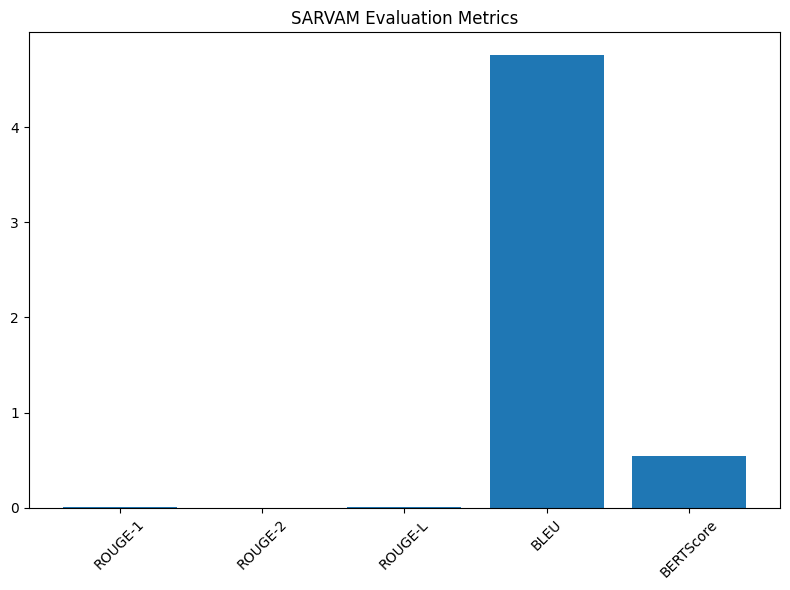

In [ ]:
# ============================================================
# METRICS PLOT
# ============================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Score"]
)

plt.xticks(rotation=45)
plt.title("SARVAM Evaluation Metrics")
plt.tight_layout()

plot_path = os.path.join(PROJECT_DIR, "sarvam_metrics_plot.png")

plt.savefig(plot_path, dpi=300)

plt.show()

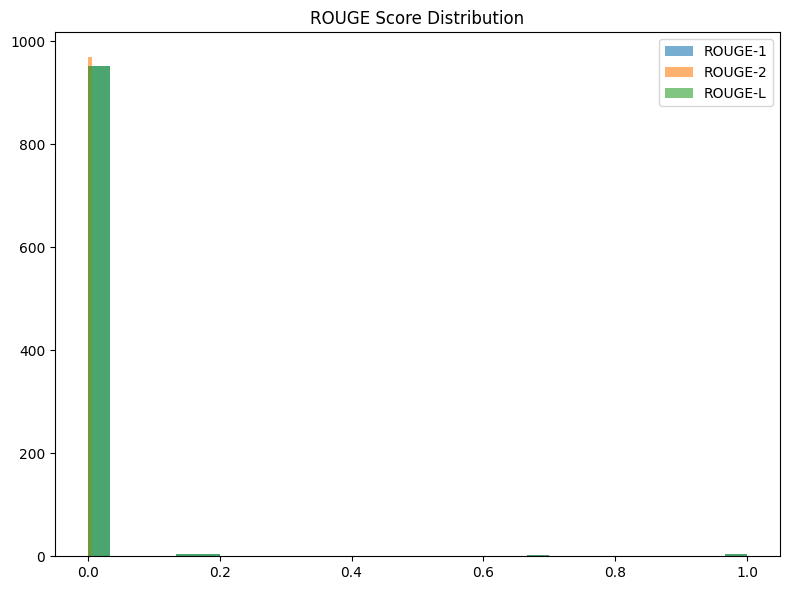

In [ ]:
# ============================================================
# ROUGE DISTRIBUTION
# ============================================================
rouge_df = pd.DataFrame({
    "ROUGE-1": r1,
    "ROUGE-2": r2,
    "ROUGE-L": rl
})

plt.figure(figsize=(8,6))

plt.hist(rouge_df["ROUGE-1"], bins=30, alpha=0.6, label="ROUGE-1")
plt.hist(rouge_df["ROUGE-2"], bins=30, alpha=0.6, label="ROUGE-2")
plt.hist(rouge_df["ROUGE-L"], bins=30, alpha=0.6, label="ROUGE-L")

plt.legend()
plt.title("ROUGE Score Distribution")
plt.tight_layout()

rouge_plot_path = os.path.join(PROJECT_DIR, "sarvam_rouge_distribution.png")

plt.savefig(rouge_plot_path, dpi=300)

plt.show()

In [ ]:
# ============================================================
# SAVE PER-SAMPLE ROUGE
# ============================================================
rouge_detail_path = os.path.join(PROJECT_DIR, "sarvam_rouge_scores.csv")

rouge_df.to_csv(rouge_detail_path, index=False)

print(rouge_detail_path)

/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT/sarvam_rouge_scores.csv


In [ ]:
# ============================================================
# TEXT REPORT
# ============================================================
report_path = os.path.join(PROJECT_DIR, "sarvam_report.txt")

with open(report_path, "w", encoding="utf-8") as f:
    f.write("SARVAM SUMMARIZATION EVALUATION REPORT\n")
    f.write("="*50 + "\n\n")

    for _, row in metrics_df.iterrows():
        f.write(f"{row['Metric']}: {row['Score']:.4f}\n")

print(report_path)

/content/drive/MyDrive/SARVAM_EVALUATION_PROJECT/sarvam_report.txt
